In [1]:
# Make video frame and mask overlay in two separate rows 

# need to be probed 

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import cv2
from scipy import stats
from scipy.ndimage import zoom

# Configuration
GESTALT_BASE_PATH = '/home/esli/GenParticles_neural_stimulus/assets/from_thomas'
SEGANYMO_BASE_PATH = '/home/esli/SegAnyMo/gestalt_SegAnyMo_outputs'
HDGMM_BASE_PATH = '/home/esli/GenParticles_neural_stimulus/video_gestalt_masks'
OUTPUT_DIR = '/home/esli/GenParticles_neural_stimulus/analysis_results'

# Helper functions to load masks
def load_ground_truth_mask(scene, frame_idx):
    """Load ground truth binary mask (1000×1000)"""
    mask_file = os.path.join(GESTALT_BASE_PATH, scene, 'render_passes', 'masks', f'Image{frame_idx+1:04d}.png')
    if not os.path.exists(mask_file):
        return None
    mask_img = np.array(Image.open(mask_file))
    if mask_img.ndim == 3:
        mask_img = mask_img[:, :, 0]
    return mask_img > 127

def load_seganymo_mask(scene, texture, frame_idx):
    """Load SegAnyMo mask (1000×1000)
    
    SegAnyMo masks are typically grayscale images. For probabilistic segmentation,
    we need to treat them as having distinct segments. If the mask has many unique
    grayscale values, we should threshold it to create a binary mask (object vs background)
    or cluster similar values together.
    """
    mask_file = os.path.join(SEGANYMO_BASE_PATH, f'{scene}_{texture}', 'sam2', 'initial_preds', 
                              'output_six_frame', f'{frame_idx:05d}.png')
    if not os.path.exists(mask_file):
        return None
    mask_img = np.array(Image.open(mask_file))
    mask = mask_img[:, :, 0] if mask_img.ndim == 3 else mask_img
    
    # For probabilistic segmentation, we need segment IDs
    # SegAnyMo masks are typically binary (0 = background, non-zero = object)
    # or have a few distinct segments. If there are many unique values,
    # we should threshold to create a binary mask.
    unique_vals = np.unique(mask)
    
    if len(unique_vals) <= 2:
        # Binary mask - convert to 0/1 segment IDs
        mask = (mask > 0).astype(int)
    elif len(unique_vals) <= 20:
        # Few segments - map each unique value to a segment ID
        segment_map = {val: idx for idx, val in enumerate(unique_vals)}
        mask_mapped = np.zeros_like(mask, dtype=int)
        for val, seg_id in segment_map.items():
            mask_mapped[mask == val] = seg_id
        mask = mask_mapped
    else:
        # Many unique values (likely grayscale) - threshold to binary
        # Use median as threshold to separate object from background
        threshold = np.median(unique_vals)
        mask = (mask > threshold).astype(int)
    
    return mask

def load_flowsam_mask(scene, texture, frame_idx):
    """Load FlowSAM mask (1000×1000), colored by detected objects"""
    # Try flowsam directory first (has different masks per frame)
    mask_file = os.path.join(GESTALT_BASE_PATH, scene, texture, 'masks', 'flowsam', 
                              f'frame_{frame_idx:04d}_segmentation_indexed.png')
    if not os.path.exists(mask_file):
        # Fallback to flowsam_matched_reprocessed
        mask_file = os.path.join(GESTALT_BASE_PATH, scene, texture, 'masks', 'flowsam_matched_reprocessed', 
                                  f'frame_{frame_idx:05d}_matched.png')
        if not os.path.exists(mask_file):
            return None
    mask_img = np.array(Image.open(mask_file))
    return mask_img[:, :, 0] if mask_img.ndim == 3 else mask_img

def load_hdgmm_mask_single_run(scene, texture, frame_idx, run_idx=0):
    """Load HDGMM mask from single run (96×96)"""
    path = os.path.join(HDGMM_BASE_PATH, scene, texture, f'run_{run_idx}', 'assignments.npz')
    if not os.path.exists(path):
        return None
    data = np.load(path, allow_pickle=True)
    if 'pixel_hyperblob_assignments' not in data or frame_idx >= len(data['pixel_hyperblob_assignments']):
        return None
    return data['pixel_hyperblob_assignments'][frame_idx].astype(np.int32)

def load_hdgmm_mask(scene, texture, frame_idx, num_runs=5):
    """Load HDGMM mask averaged across runs using mode (96×96)"""
    masks = [load_hdgmm_mask_single_run(scene, texture, frame_idx, i) for i in range(num_runs)]
    masks = [m for m in masks if m is not None]
    if len(masks) == 0:
        return None
    if len(masks) == 1:
        return masks[0]
    masks_stack = np.stack(masks, axis=0)
    mode_mask, _ = stats.mode(masks_stack, axis=0, keepdims=False)
    return mode_mask.astype(np.int32)

def load_video_frames(video_path):
    """Load video frames from MP4 file."""
    if not os.path.exists(video_path):
        print(f"Video file not found: {video_path}")
        return None
    
    cap = cv2.VideoCapture(video_path)
    frames = []
    
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        # Convert BGR to RGB
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frames.append(frame_rgb)
    
    cap.release()
    
    if len(frames) == 0:
        print(f"No frames loaded from {video_path}")
        return None
    
    return frames

def create_probabilistic_segmentation_from_probes(true_mask, predicted_mask, num_probes=100, random_seed=None):
    """
    Create probabilistic segmentation by averaging binary segmentations from probe points.
    
    Methodology:
    1. Sample probe points from ground truth object region
    2. For each probe, get the segment ID it belongs to in predicted mask
    3. Create binary mask for that segment
    4. Average all binary masks to get probabilistic segmentation (0-1 values)
    
    Args:
        true_mask: Ground truth binary mask (H, W)
        predicted_mask: Predicted segmentation mask (H, W) with segment IDs
        num_probes: Number of probe points to sample
        random_seed: Random seed for reproducibility
    
    Returns:
        probabilistic_mask: Float array (H, W) with values in [0, 1] representing
                           probability that pixel belongs to object
        probe_locations: List of (y, x) coordinates of probe points
    """
    if true_mask is None or predicted_mask is None:
        return None, []
    
    # Resize predicted mask to match true mask if needed
    if true_mask.shape != predicted_mask.shape:
        zoom_factors = (true_mask.shape[0] / predicted_mask.shape[0], 
                       true_mask.shape[1] / predicted_mask.shape[1])
        predicted_mask = zoom(predicted_mask.astype(float), zoom_factors, order=0).astype(int)
    
    # Flatten masks
    h, w = true_mask.shape
    true_flat = true_mask.flatten()
    pred_flat = predicted_mask.flatten()
    
    # Sample probe points from object region
    object_indices = np.where(true_flat)[0]
    if len(object_indices) == 0:
        return np.zeros_like(true_mask, dtype=np.float32), []
    
    # Set random seed BEFORE sampling
    if random_seed is not None:
        np.random.seed(int(random_seed))
    else:
        # If no seed provided, use current state
        pass
    
    num_samples = min(num_probes, len(object_indices))
    probe_indices = np.random.choice(object_indices, size=num_samples, replace=False)
    
    # Convert flat indices to (y, x) coordinates
    probe_locations = [(idx // w, idx % w) for idx in probe_indices]
    
    # Initialize accumulator for probabilistic mask
    prob_mask = np.zeros((h, w), dtype=np.float32)
    
    # For each probe point, create binary mask for its segment and accumulate
    for probe_idx in probe_indices:
        segment_id = pred_flat[probe_idx]
        # Create binary mask for this segment
        segment_mask = (pred_flat == segment_id).reshape(h, w)
        # Accumulate (will average later)
        prob_mask = prob_mask + segment_mask.astype(np.float32)
    
    # Average to get probabilistic mask
    if num_samples > 0:
        prob_mask = prob_mask / num_samples
    
    return prob_mask, probe_locations

def overlay_mask_on_frame(frame, mask, alpha=0.5, cmap='tab20', is_probabilistic=False, prob_range=None):
    """Overlay a mask on a video frame.
    
    Args:
        frame: Video frame (H, W, 3)
        mask: Mask to overlay (H, W) - can be binary, integer segment IDs, or probabilistic [0, 1]
        alpha: Transparency of overlay
        cmap: Colormap to use
        is_probabilistic: If True, mask is already probabilistic [0, 1]. If False, will normalize.
        prob_range: Tuple (min, max) for standardizing probabilistic masks across all plots.
                   If None, will use mask's own min/max.
    """
    if mask is None:
        return frame
    
    # Resize mask to match frame dimensions if needed
    if mask.shape[:2] != frame.shape[:2]:
        zoom_factors = (frame.shape[0] / mask.shape[0], frame.shape[1] / mask.shape[1])
        mask_resized = zoom(mask.astype(float), zoom_factors, order=1 if is_probabilistic else 0)
    else:
        mask_resized = mask
    
    # Normalize mask to 0-1 range for colormap
    if is_probabilistic:
        # Probabilistic mask - use global range for standardization if provided
        if prob_range is not None:
            prob_min, prob_max = prob_range
            # Clip to global range and normalize to [0, 1]
            mask_clipped = np.clip(mask_resized, prob_min, prob_max)
            if prob_max > prob_min:
                mask_normalized = (mask_clipped - prob_min) / (prob_max - prob_min + 1e-8)
            else:
                mask_normalized = np.zeros_like(mask_clipped, dtype=np.float32)
        else:
            # Fallback: use mask's own range
            mask_min = mask_resized.min()
            mask_max = mask_resized.max()
            if mask_max > mask_min:
                mask_normalized = (mask_resized - mask_min) / (mask_max - mask_min + 1e-8)
            else:
                mask_normalized = np.clip(mask_resized.astype(np.float32), 0.0, 1.0)
    else:
        # Not probabilistic - normalize based on type
        if mask_resized.dtype != np.float32:
            mask_resized = mask_resized.astype(np.float32)
        
        unique_vals = np.unique(mask_resized)
        if len(unique_vals) == 1:
            # Single value mask - use binary overlay
            mask_normalized = (mask_resized > 0).astype(np.float32)
        else:
            # Multi-value mask - normalize to 0-1
            mask_normalized = (mask_resized - mask_resized.min()) / (mask_resized.max() - mask_resized.min() + 1e-8)
    
    # Apply colormap
    cmap_obj = plt.get_cmap(cmap)
    mask_colored = cmap_obj(mask_normalized)[:, :, :3]  # Remove alpha channel
    mask_colored = (mask_colored * 255).astype(np.uint8)
    
    # Overlay mask on frame
    overlay = (1 - alpha) * frame + alpha * mask_colored
    return overlay.astype(np.uint8)

Loaded 6 frames from video

Loading masks for frame 0:
  Ground Truth: ✓
  FlowSAM: ✓
  GenMatter (HDGMM): ✓
  Creating probabilistic segmentations from 100 probe points...

Loading masks for frame 4:
  Ground Truth: ✓
  FlowSAM: ✓
  GenMatter (HDGMM): ✓
  Creating probabilistic segmentations from 100 probe points...

Global probability range: [0.0000, 0.9800]

Segmentation Comparison: scene_00016 - texture_07

Figure saved to: /home/esli/GenParticles_neural_stimulus/analysis_results/paper_figure_comparison_scene_00016_texture_07_frames0_4.pdf


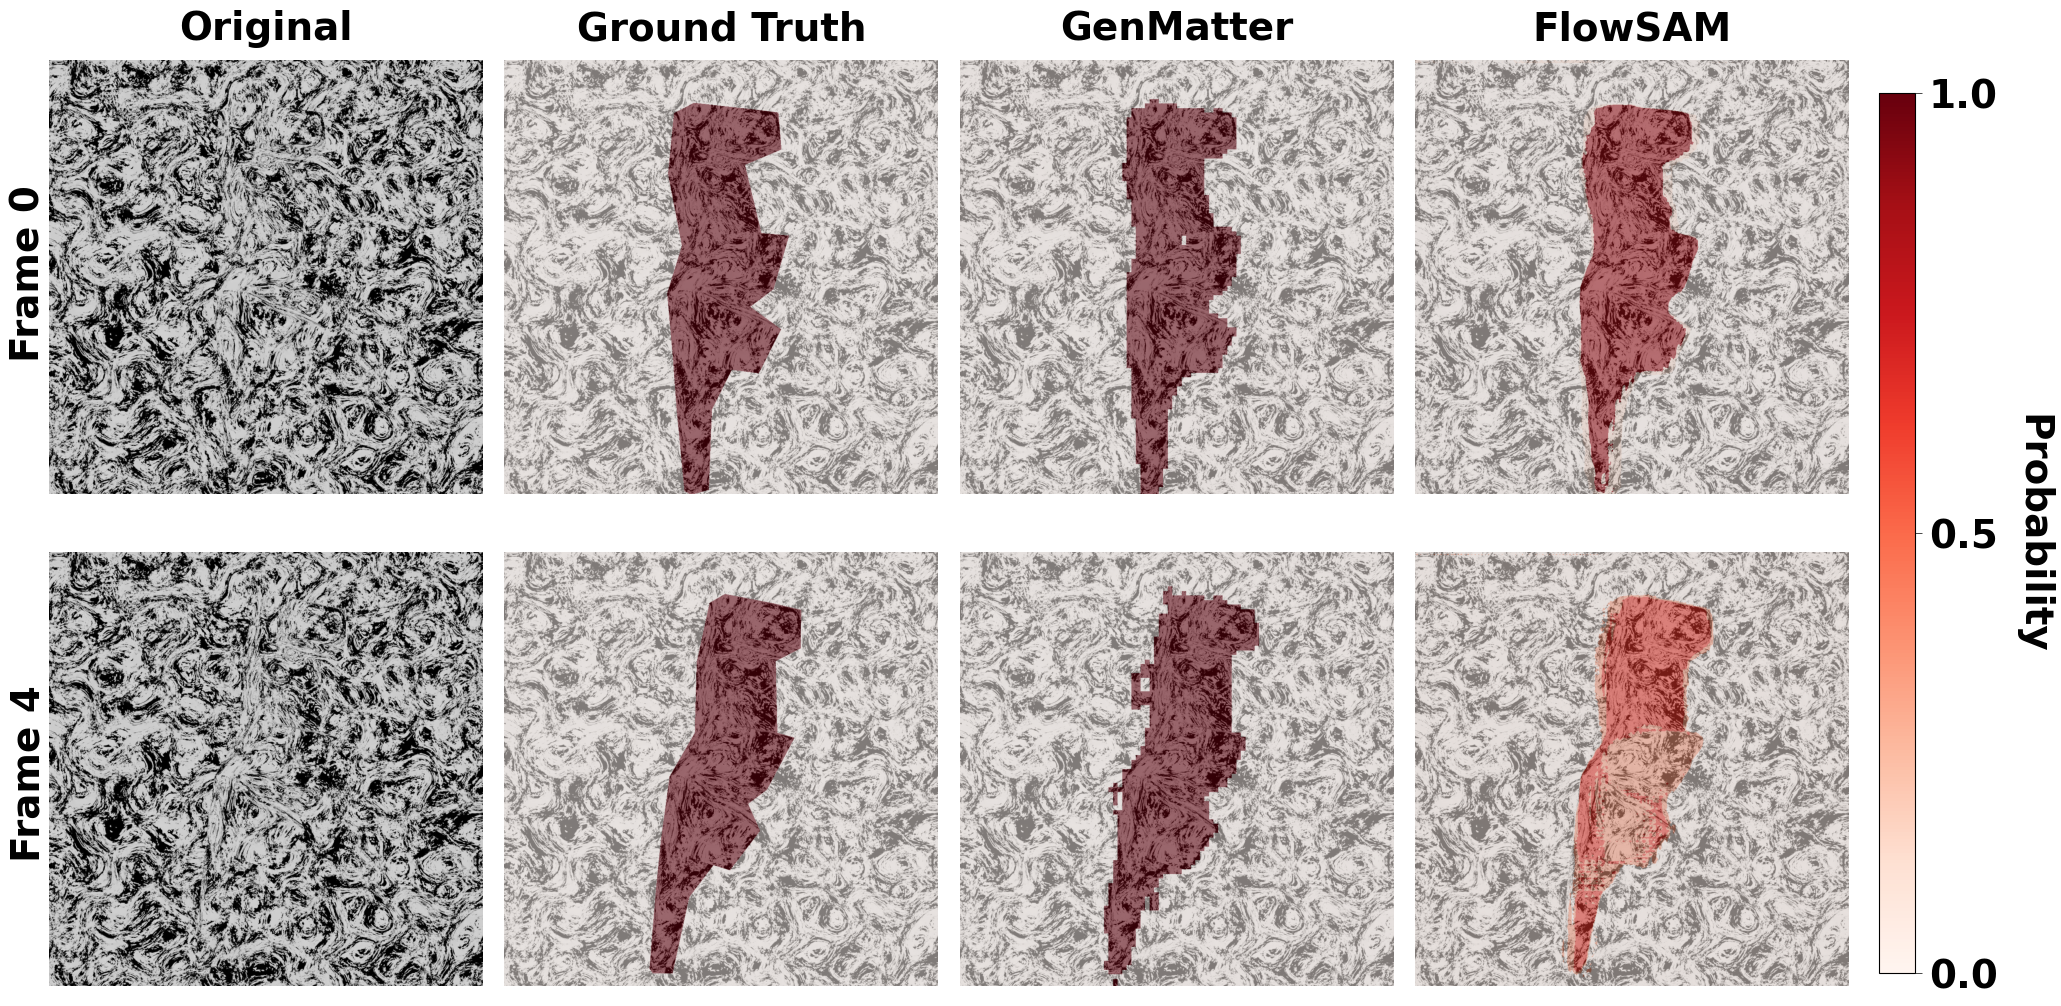

In [3]:
# Create visualization figure showing all methods for two frames
# Layout: 2 rows x 4 or 5 columns (depending on INCLUDE_SEGANYMO flag)
# Row 1: Frame 0 - [Original] [Ground Truth] [GenMatter] [FlowSAM] [SegAnyMo if enabled]
# Row 2: Frame 4 - [Original] [Ground Truth] [GenMatter] [FlowSAM] [SegAnyMo if enabled]

# Flags to temporarily turn off features
INCLUDE_SEGANYMO = False
SHOW_PROBE_POINTS = False

scene = 'scene_00016'
texture = 'texture_07'
frame_indices = [0, 4]  # Frames to display

# Load video frames
video_path = os.path.join(GESTALT_BASE_PATH, scene, texture, 'output_six_frame.mp4')
frames = load_video_frames(video_path)

if frames is None:
    print(f"Could not load video frames from {video_path}")
else:
    print(f"Loaded {len(frames)} frames from video")
    
    # Create figure: 2 rows x 4 or 5 columns (depending on INCLUDE_SEGANYMO)
    num_cols = 4 if not INCLUDE_SEGANYMO else 5
    fig_width = 20 if not INCLUDE_SEGANYMO else 25
    fig, axes = plt.subplots(2, num_cols, figsize=(fig_width, 10))
    
    for row_idx, frame_idx in enumerate(frame_indices):
        if frame_idx >= len(frames):
            print(f"Frame {frame_idx} not available (only {len(frames)} frames)")
            continue
            
        frame = frames[frame_idx]
        
        # Load all masks for this frame
        print(f"\nLoading masks for frame {frame_idx}:")
        
        # Ground Truth: frame_idx+1 (1-indexed)
        gt_mask = load_ground_truth_mask(scene, frame_idx)
        print(f"  Ground Truth: {'✓' if gt_mask is not None else '✗'}")
        
        # SegAnyMo: frame_idx (0-indexed) - only load if enabled
        seganymo_mask = None
        if INCLUDE_SEGANYMO:
            seganymo_mask = load_seganymo_mask(scene, texture, frame_idx)
            print(f"  SegAnyMo: {'✓' if seganymo_mask is not None else '✗'}")
        
        # FlowSAM: frame_idx (0-indexed, but uses 4-digit format in flowsam directory)
        flowsam_mask = load_flowsam_mask(scene, texture, frame_idx)
        print(f"  FlowSAM: {'✓' if flowsam_mask is not None else '✗'}")
        
        # HDGMM/GenMatter: frame_idx (0-indexed)
        hdgmm_mask = load_hdgmm_mask(scene, texture, frame_idx)
        print(f"  GenMatter (HDGMM): {'✓' if hdgmm_mask is not None else '✗'}")
        
        # Create probabilistic segmentations using probe points
        # Use deterministic seed based on scene, texture, and frame for reproducibility
        scene_num = int(scene.split('_')[1])
        texture_num = int(texture.split('_')[1])
        base_seed = 42 + scene_num * 1000 + texture_num * 10 + frame_idx
        
        # Create probabilistic masks for each method (except Ground Truth)
        print(f"  Creating probabilistic segmentations from 100 probe points...")
        
        # Resize GT mask to match frame dimensions for probe sampling
        if gt_mask.shape[:2] != frame.shape[:2]:
            zoom_factors = (frame.shape[0] / gt_mask.shape[0], frame.shape[1] / gt_mask.shape[1])
            gt_mask_resized = zoom(gt_mask.astype(float), zoom_factors, order=0) > 0.5
        else:
            gt_mask_resized = gt_mask
        
        # Use the same random seed for all methods to get consistent probe points
        # This ensures fair comparison and allows us to visualize the same probe locations
        probe_seed = base_seed
        
        # GenMatter: Create probabilistic segmentation
        hdgmm_prob = None
        probe_locations = None
        if hdgmm_mask is not None:
            # Resize HDGMM mask to match frame dimensions
            if hdgmm_mask.shape[:2] != frame.shape[:2]:
                zoom_factors = (frame.shape[0] / hdgmm_mask.shape[0], frame.shape[1] / hdgmm_mask.shape[1])
                hdgmm_resized = zoom(hdgmm_mask.astype(float), zoom_factors, order=0).astype(int)
            else:
                hdgmm_resized = hdgmm_mask
            hdgmm_prob, probe_locations = create_probabilistic_segmentation_from_probes(
                gt_mask_resized, hdgmm_resized, num_probes=100, random_seed=probe_seed
            )
        
        # SegAnyMo: Create probabilistic segmentation (use same probe points) - only if enabled
        seganymo_prob = None
        if INCLUDE_SEGANYMO and seganymo_mask is not None:
            # Resize SegAnyMo mask to match frame dimensions
            if seganymo_mask.shape[:2] != frame.shape[:2]:
                zoom_factors = (frame.shape[0] / seganymo_mask.shape[0], frame.shape[1] / seganymo_mask.shape[1])
                seganymo_resized = zoom(seganymo_mask.astype(float), zoom_factors, order=0).astype(int)
            else:
                seganymo_resized = seganymo_mask
            
            seganymo_prob, _ = create_probabilistic_segmentation_from_probes(
                gt_mask_resized, seganymo_resized, num_probes=100, random_seed=probe_seed
            )
        
        # FlowSAM: Create probabilistic segmentation (use same probe points)
        flowsam_prob = None
        if flowsam_mask is not None:
            # Resize FlowSAM mask to match frame dimensions
            if flowsam_mask.shape[:2] != frame.shape[:2]:
                zoom_factors = (frame.shape[0] / flowsam_mask.shape[0], frame.shape[1] / flowsam_mask.shape[1])
                flowsam_resized = zoom(flowsam_mask.astype(float), zoom_factors, order=0).astype(int)
            else:
                flowsam_resized = flowsam_mask
            flowsam_prob, _ = create_probabilistic_segmentation_from_probes(
                gt_mask_resized, flowsam_resized, num_probes=100, random_seed=probe_seed
            )
        
        # Store probabilistic masks for later standardization
        if not hasattr(fig, '_prob_masks'):
            fig._prob_masks = []
        if hdgmm_prob is not None:
            fig._prob_masks.append(hdgmm_prob)
        if INCLUDE_SEGANYMO and seganymo_prob is not None:
            fig._prob_masks.append(seganymo_prob)
        if flowsam_prob is not None:
            fig._prob_masks.append(flowsam_prob)
        
        # Store masks and frame for later rendering (after we compute global range)
        if not hasattr(fig, '_render_data'):
            fig._render_data = []
        fig._render_data.append({
            'row_idx': row_idx,
            'frame': frame,
            'gt_mask': gt_mask_resized,
            'hdgmm_prob': hdgmm_prob,
            'seganymo_prob': seganymo_prob if INCLUDE_SEGANYMO else None,
            'flowsam_prob': flowsam_prob,
            'frame_idx': frame_idx,
            'probe_locations': probe_locations
        })
    
    # Standardize probabilistic masks across all plots
    # Find global min/max across all probabilistic masks
    if hasattr(fig, '_prob_masks') and len(fig._prob_masks) > 0:
        all_probs = np.concatenate([m.flatten() for m in fig._prob_masks if m is not None])
        global_prob_min = all_probs.min()
        global_prob_max = all_probs.max()
        print(f"\nGlobal probability range: [{global_prob_min:.4f}, {global_prob_max:.4f}]")
        
        # Store global range for use in overlay function
        global_prob_range = (global_prob_min, global_prob_max)
    else:
        global_prob_range = (0.0, 1.0)
    
    # Now render all plots with standardized probability range
    for render_data in fig._render_data:
        row_idx = render_data['row_idx']
        frame = render_data['frame']
        gt_mask_resized = render_data['gt_mask']
        hdgmm_prob = render_data['hdgmm_prob']
        seganymo_prob = render_data['seganymo_prob']
        flowsam_prob = render_data['flowsam_prob']
        frame_idx = render_data['frame_idx']
        probe_locations = render_data['probe_locations']
        
        # Define methods in order: [Original] [Ground Truth] [GenMatter] [FlowSAM] [SegAnyMo if enabled]
        methods = [
            ('Original', None, None, False, None),  # No mask, just show frame
            ('Ground Truth', gt_mask_resized, 'Reds', False, None),  # Binary mask, not probabilistic
            ('GenMatter', hdgmm_prob, 'Reds', True, global_prob_range),  # Probabilistic
            ('FlowSAM', flowsam_prob, 'Reds', True, global_prob_range)  # Probabilistic
        ]
        
        # Add SegAnyMo only if enabled
        if INCLUDE_SEGANYMO:
            methods.append(('SegAnyMo', seganymo_prob, 'Reds', True, global_prob_range))
        
        for col_idx, (method_name, mask, cmap, is_prob, prob_range) in enumerate(methods):
            if mask is None:
                # Original frame - no overlay
                axes[row_idx, col_idx].imshow(frame)
                # Only set title for top row (significantly larger font)
                if row_idx == 0:
                    axes[row_idx, col_idx].set_title(method_name, fontsize=28, fontweight='bold', pad=15)
            else:
                # Create overlay with probabilistic mask (using global range for standardization)
                overlay = overlay_mask_on_frame(frame, mask, alpha=0.5, cmap=cmap, 
                                                is_probabilistic=is_prob, prob_range=prob_range)
                axes[row_idx, col_idx].imshow(overlay)
                
                # Add probe points on Ground Truth mask (only if enabled)
                if SHOW_PROBE_POINTS and method_name == 'Ground Truth' and probe_locations is not None and len(probe_locations) > 0:
                    # Plot probe points as dark blue circles (smaller)
                    y_coords = [loc[0] for loc in probe_locations]
                    x_coords = [loc[1] for loc in probe_locations]
                    axes[row_idx, col_idx].scatter(x_coords, y_coords, c='darkblue', s=40, 
                                                   edgecolors='black', linewidths=0.8, alpha=0.9, zorder=10)
                
                # Only set title for top row (significantly larger font)
                if row_idx == 0:
                    axes[row_idx, col_idx].set_title(method_name, fontsize=28, fontweight='bold', pad=15)
            
            axes[row_idx, col_idx].axis('off')
        
        # Add row label on the left (significantly larger font)
        fig.text(0.01, 0.75 - row_idx * 0.5, f'Frame {frame_idx}', 
             fontsize=28, fontweight='bold', rotation=90, va='center', ha='center')
    
    # Print title to console instead of including in figure
    plot_title = f'Segmentation Comparison: {scene} - {texture}'
    print(f"\n{plot_title}")
    
    # Add colorbar for probability scale
    # Create a scalar mappable for the colorbar
    from matplotlib.colors import Normalize
    from matplotlib.cm import ScalarMappable
    
    prob_min, prob_max = global_prob_range
    norm = Normalize(vmin=prob_min, vmax=prob_max)
    sm = ScalarMappable(cmap=plt.get_cmap('Reds'), norm=norm)
    sm.set_array([])
    
    # Use subplots_adjust to position subplots and leave room for colorbar
    # Tighten row spacing to match column spacing (wspace = hspace)
    plt.subplots_adjust(left=0.02, right=0.92, top=0.98, bottom=0.02, wspace=0.05, hspace=0.05)
    
    # Add colorbar positioned at the right edge of the figure
    # Create a new axes for the colorbar at the right edge (shorter and wider)
    # [left, bottom, width, height] - make it wider and shorter to avoid overrunning bottom
    cbar_ax = fig.add_axes([0.935, 0.05, 0.018, 0.88])  # Wider (0.018) and shorter (0.88), raised bottom (0.05)
    cbar = fig.colorbar(sm, cax=cbar_ax, orientation='vertical')
    
    # Publication-quality label and tick formatting (significantly larger font)
    cbar.set_label('Probability', fontsize=28, fontweight='bold', rotation=270, 
                   labelpad=25, y=0.5, va='center', ha='center')
    
    # Set custom tick locations: only show 0.0, 0.5, and 1.0
    # Map these to the actual probability range
    prob_min, prob_max = global_prob_range
    tick_values = [prob_min, (prob_min + prob_max) / 2, prob_max]
    tick_labels = ['0.0', '0.5', '1.0']
    cbar.set_ticks(tick_values)
    cbar.set_ticklabels(tick_labels)
    
    # Significantly larger tick labels, bold
    cbar.ax.tick_params(labelsize=28, length=5, width=0.5, pad=5)
    # Make tick labels bold
    for label in cbar.ax.get_yticklabels():
        label.set_fontweight('bold')
    
    # Save figure as PDF
    output_path = os.path.join(OUTPUT_DIR, f'paper_figure_comparison_{scene}_{texture}_frames{frame_indices[0]}_{frame_indices[1]}.pdf')
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    plt.savefig(output_path, format='pdf', bbox_inches='tight')
    print(f"\nFigure saved to: {output_path}")
    
    plt.show()


Loaded 6 frames from video
Frame 0: SegAnyMo has 1 segments (IDs: [1])
Frame 4: SegAnyMo has 1 segments (IDs: [1])



Figure saved to: /home/esli/GenParticles_neural_stimulus/analysis_results/seganymo_inferred_masks_scene_00016_texture_07_frames0_4.png


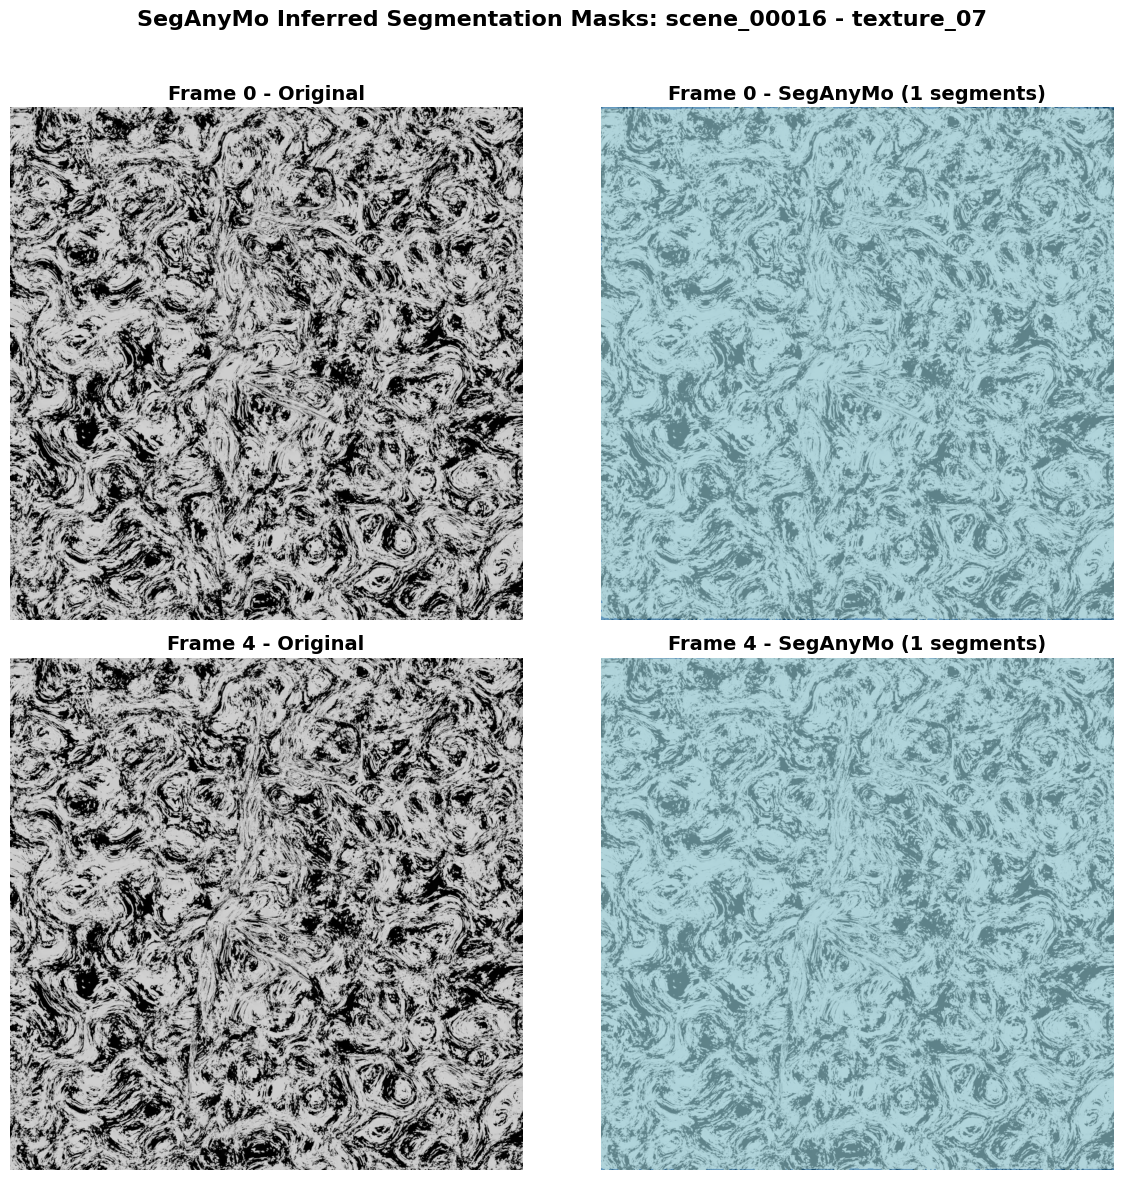

In [4]:
# Show SegAnyMo inferred segmentation masks separately
# This displays the raw SegAnyMo masks with their segment IDs

frame_indices = [0, 4]  # Frames to display

# Load video frames
video_path = os.path.join(GESTALT_BASE_PATH, scene, texture, 'output_six_frame.mp4')
frames = load_video_frames(video_path)

if frames is None:
    print(f"Could not load video frames from {video_path}")
else:
    print(f"Loaded {len(frames)} frames from video")
    
    # Create figure: 2 rows x 2 columns (original frame + SegAnyMo mask for each frame)
    fig, axes = plt.subplots(2, 2, figsize=(12, 12))
    
    for row_idx, frame_idx in enumerate(frame_indices):
        if frame_idx >= len(frames):
            print(f"Frame {frame_idx} not available (only {len(frames)} frames)")
            continue
            
        frame = frames[frame_idx]
        
        # Load SegAnyMo mask (raw, with segment IDs)
        seganymo_mask = load_seganymo_mask(scene, texture, frame_idx)
        
        if seganymo_mask is None:
            print(f"  SegAnyMo mask not available for frame {frame_idx}")
            continue
        
        # Left column: Original frame
        axes[row_idx, 0].imshow(frame)
        axes[row_idx, 0].set_title(f'Frame {frame_idx} - Original', fontsize=14, fontweight='bold')
        axes[row_idx, 0].axis('off')
        
        # Right column: SegAnyMo inferred segmentation mask
        # Resize mask to match frame dimensions
        if seganymo_mask.shape[:2] != frame.shape[:2]:
            zoom_factors = (frame.shape[0] / seganymo_mask.shape[0], frame.shape[1] / seganymo_mask.shape[1])
            seganymo_resized = zoom(seganymo_mask.astype(float), zoom_factors, order=0).astype(int)
        else:
            seganymo_resized = seganymo_mask
        
        # Show SegAnyMo mask with segment IDs using tab20 colormap (good for discrete segments)
        overlay = overlay_mask_on_frame(frame, seganymo_resized, alpha=0.6, cmap='tab20', is_probabilistic=False)
        axes[row_idx, 1].imshow(overlay)
        
        # Get unique segments for display
        unique_segments = np.unique(seganymo_resized)
        num_segments = len(unique_segments[unique_segments > 0])  # Exclude background (0)
        axes[row_idx, 1].set_title(f'Frame {frame_idx} - SegAnyMo ({num_segments} segments)', 
                                   fontsize=14, fontweight='bold')
        axes[row_idx, 1].axis('off')
        
        print(f"Frame {frame_idx}: SegAnyMo has {num_segments} segments (IDs: {unique_segments[unique_segments > 0]})")
    
    plt.suptitle(f'SegAnyMo Inferred Segmentation Masks: {scene} - {texture}', 
                 fontsize=16, fontweight='bold', y=0.98)
    
    plt.tight_layout(rect=[0, 0, 1, 0.96])  # Leave space for title
    
    # Save figure
    output_path = os.path.join(OUTPUT_DIR, f'seganymo_inferred_masks_{scene}_{texture}_frames{frame_indices[0]}_{frame_indices[1]}.png')
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    print(f"\nFigure saved to: {output_path}")
    
    plt.show()
